# ROGII Wellbore Geology Prediction — General EDA

Purely **descriptive** exploration: what the data is, variable distributions, ranges, missingness, structure.
No hypotheses, no baselines, no modeling — those live in later notebooks.

We predict `TVT` (depth within the rock-layer stack) for the post-PS portion of each horizontal well, using the
lateral gamma-ray (`GR`) log plus a per-well vertical reference (`typewell`).

*Reading guide: red line on each histogram = median (value labelled); tables list every number with a
plain-language meaning.*

## 1. Setup

In [1]:
%matplotlib inline
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

# ---- presentation defaults ----
plt.rcParams.update({
    "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "axes.edgecolor": "#888",
})
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
BAR, MED, ID = "#4C78A8", "#E45756", "#54A24B"

def show_metrics(title, rows):
    # 3-column Measurement | Value | What it means table
    df = pd.DataFrame(rows, columns=["Measurement", "Value", "What it means"])
    sty = (df.style.hide(axis="index").set_caption(title)
           .set_properties(**{"text-align": "left", "font-size": "12px", "padding": "4px 12px"})
           .set_table_styles([
               {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"),
                                                  ("text-align", "left"), ("padding", "6px 0")]},
               {"selector": "th", "props": [("text-align", "left"), ("background", "#eef1f6"),
                                            ("padding", "4px 12px")]}]))
    display(sty)

def hist_annot(ax, data, title, xlabel, fmt=lambda v: f"{v:,.1f}", bins=40, ylabel="wells"):
    # histogram with median line + labelled value
    d = pd.Series(data).dropna()
    ax.hist(d, bins=bins, color=BAR, edgecolor="white", linewidth=0.3)
    med = d.median()
    ax.axvline(med, color=MED, lw=2)
    ax.text(0.97, 0.95, f"median {fmt(med)}", transform=ax.transAxes, ha="right", va="top",
            fontsize=10, bbox=dict(boxstyle="round", fc="white", ec=MED, alpha=0.9))
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)

ft0  = lambda v: f"{v:,.0f} ft"
n0   = lambda v: f"{v:,.0f}"
pct0 = lambda v: f"{v*100:.0f}%"

def stat_row(s, fmt):
    q = s.quantile([0.5, 0.25, 0.75])
    return {"median": fmt(q[0.5]), "p25": fmt(q[0.25]), "p75": fmt(q[0.75]),
            "min": fmt(s.min()), "max": fmt(s.max())}

def find_data_root():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / "data" / "raw" / "train").is_dir():
            return (c / "data" / "raw").resolve()
        if (c / "train").is_dir() and (c / "sample_submission.csv").is_file():
            return c.resolve()
    raise FileNotFoundError("data root not found")

DATA = find_data_root()
TRAIN, TEST = DATA / "train", DATA / "test"
PROCESSED = DATA.parent / "processed"; PROCESSED.mkdir(exist_ok=True)
LAYER_COLS = ["ANCC", "ASTNU", "ASTNL", "EGFDU", "EGFDL", "BUDA"]
def wid(p): return Path(p).name.split("__")[0]
def tw_path(p): return str(p).replace("__horizontal_well", "__typewell")

train_h = sorted(TRAIN.glob("*__horizontal_well.csv"))
test_h  = sorted(TEST.glob("*__horizontal_well.csv"))
print("DATA root  :", DATA)
print("train wells:", len(train_h), "| test wells:", len(test_h))

DATA root  : D:\KAGGLE\rogii-wellbore-geology-prediction\data\raw
train wells: 773 | test wells: 3


## 2. Dataset inventory

Confirm every well has its full file set and the expected columns.

In [2]:
def missing_files(ids, base, need_png):
    miss = []
    for i in ids:
        ok = (base / f"{i}__horizontal_well.csv").exists() and (base / f"{i}__typewell.csv").exists()
        if need_png: ok = ok and (base / f"{i}.png").exists()
        if not ok: miss.append(i)
    return miss

tr_ids, te_ids = [wid(p) for p in train_h], [wid(p) for p in test_h]
print("train wells missing a file:", len(missing_files(tr_ids, TRAIN, True)))
print("test  wells missing a file:", len(missing_files(te_ids, TEST, False)))

cols = pd.DataFrame({
    "file": ["horizontal (train)", "horizontal (test)", "typewell"],
    "columns": [", ".join(pd.read_csv(train_h[0], nrows=0).columns),
                ", ".join(pd.read_csv(test_h[0], nrows=0).columns),
                ", ".join(pd.read_csv(tw_path(train_h[0]), nrows=0).columns)]})
cols.style.hide(axis="index").set_properties(**{"text-align": "left"})

train wells missing a file: 0
test  wells missing a file: 0


file,columns
horizontal (train),"MD, X, Y, Z, ANCC, ASTNU, ASTNL, EGFDU, EGFDL, BUDA, TVT, GR, TVT_input"
horizontal (test),"MD, X, Y, Z, GR, TVT_input"
typewell,"TVT, GR, Geology"


## 3. Per-well summary

A single streaming pass over all 773 wells (low memory). Cached to `data/processed/well-summary.parquet` for
reuse. `PS` (Prediction Start) = first row where `TVT_input` goes blank; everything after is what we predict.

In [3]:
def summarize_well(p):
    i = wid(p)
    h = pd.read_csv(p, usecols=lambda c: c in ["MD", "X", "Y", "Z", "GR", "TVT", "TVT_input"])
    tw = pd.read_csv(tw_path(p), usecols=lambda c: c in ["TVT", "GR", "Geology"])
    n = len(h); ti, gr = h["TVT_input"], h["GR"]
    ps = int(ti.isna().values.argmax()) if ti.isna().any() else n
    pre, post = h.iloc[:ps], h.iloc[ps:]
    return {
        "well_id": i, "n_rows": n, "md_span": h.MD.max() - h.MD.min(),
        "md_step": float(np.median(np.diff(h.MD.values))) if n > 1 else np.nan,
        "x_mean": h.X.mean(), "y_mean": h.Y.mean(),
        "z_min": h.Z.min(), "z_max": h.Z.max(), "z_span": h.Z.max() - h.Z.min(),
        "gr_mean": gr.mean(), "gr_std": gr.std(), "gr_min": gr.min(), "gr_max": gr.max(),
        "gr_nan_frac": gr.isna().mean(),
        "gr_nan_frac_pre": pre["GR"].isna().mean() if len(pre) else np.nan,
        "gr_nan_frac_post": post["GR"].isna().mean() if len(post) else np.nan,
        "ps_index": ps, "ps_frac": ps / n,
        "n_predict": int(ti.isna().sum()), "predict_frac": ti.isna().mean(),
        "ti_tail_clean": int((n - ps) == int(ti.isna().sum())),
        "tvt_min": h.TVT.min(), "tvt_max": h.TVT.max(),
        "tvt_span": h.TVT.max() - h.TVT.min(), "tvt_mean": h.TVT.mean(),
        "tw_nrows": len(tw), "tw_tvt_span": tw.TVT.max() - tw.TVT.min(),
        "tw_gr_mean": tw.GR.mean(), "tw_gr_std": tw.GR.std(),
        "tw_gr_min": tw.GR.min(), "tw_gr_max": tw.GR.max(),
        "n_geology": tw["Geology"].nunique() if "Geology" in tw else np.nan,
        "gr_scale_gap": gr.mean() - tw.GR.mean(),
    }

S = pd.DataFrame([summarize_well(p) for p in train_h])
S.to_parquet(PROCESSED / "well-summary.parquet", index=False)
print(f"summarised {len(S)} wells | all PS tails clean: {bool((S.ti_tail_clean == 1).all())}")

summarised 773 wells | all PS tails clean: True


**Key numbers**

In [4]:
show_metrics("Dataset at a glance", [
    ["Training wells", f"{len(train_h):,}", "each: one GR log + typewell + figure"],
    ["Test wells (visible)", f"{len(test_h)}", "code competition — scored test is larger & hidden"],
    ["Rows per well", f"~{S.n_rows.median():,.0f} (median)", "one row per foot drilled (1-ft spacing)"],
    ["Part to predict", f"~{S.predict_frac.median()*100:.0f}% of each well", "PS sits early → long extrapolation"],
    ["GR missing", f"~{S.gr_nan_frac.median()*100:.0f}% (up to {S.gr_nan_frac.max()*100:.0f}%)", "denser after PS than before"],
    ["GR scale vs typewell", "varies per well", "normalize GR per well, not globally"],
    ["TVT span / well", f"~{S.tvt_span.median():,.0f} ft", "total depth range a well covers"],
    ["Geology labels", f"{int(S.n_geology.max())} seen, 6 common", "6 formations appear in nearly every well"],
])

Measurement,Value,What it means
Training wells,773,each: one GR log + typewell + figure
Test wells (visible),3,code competition — scored test is larger & hidden
Rows per well,"~6,576 (median)",one row per foot drilled (1-ft spacing)
Part to predict,~74% of each well,PS sits early → long extrapolation
GR missing,~28% (up to 80%),denser after PS than before
GR scale vs typewell,varies per well,"normalize GR per well, not globally"
TVT span / well,~758 ft,total depth range a well covers
Geology labels,"21 seen, 6 common",6 formations appear in nearly every well


**Per-well statistic spread** (median, quartiles, min, max — formatted, no scientific notation)

In [5]:
T = pd.DataFrame({
    "rows per well":          stat_row(S.n_rows, n0),
    "MD step (ft)":           stat_row(S.md_step, lambda v: f"{v:.2f}"),
    "Z span (ft)":            stat_row(S.z_span, ft0),
    "GR mean":                stat_row(S.gr_mean, lambda v: f"{v:.1f}"),
    "GR missing":             stat_row(S.gr_nan_frac, pct0),
    "known part of well":     stat_row(S.ps_frac, pct0),
    "rows to predict":        stat_row(S.n_predict, n0),
    "TVT span (ft)":          stat_row(S.tvt_span, ft0),
    "typewell TVT span (ft)": stat_row(S.tw_tvt_span, ft0),
    "formations / well":      stat_row(S.n_geology, lambda v: f"{v:.0f}"),
}).T[["median", "p25", "p75", "min", "max"]]
T.style.set_properties(**{"text-align": "right", "font-size": "12px"})

,median,p25,p75,min,max
rows per well,"6,576","5,706","7,388","2,058","12,141"
MD step (ft),1.00,1.00,1.00,1.00,1.00
Z span (ft),787 ft,692 ft,910 ft,198 ft,"1,412 ft"
GR mean,86.6,80.1,93.5,37.2,130.5
GR missing,28%,12%,46%,1%,80%
known part of well,26%,22%,30%,12%,80%
rows to predict,"4,840","4,044","5,694",407,"10,052"
TVT span (ft),758 ft,589 ft,857 ft,159 ft,"1,257 ft"
typewell TVT span (ft),907 ft,745 ft,"1,012 ft",322 ft,"1,399 ft"
formations / well,6,6,7,4,21


## 4. Lateral size & geometry

How long the wells are, how finely sampled, and where they sit in space.

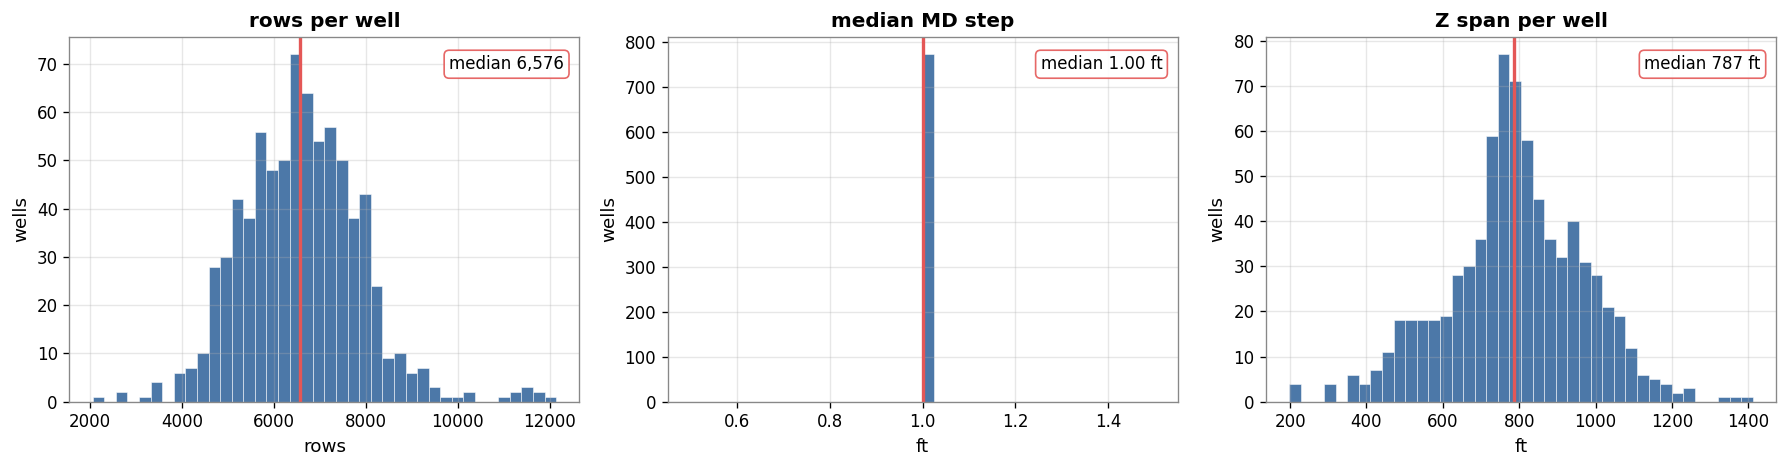

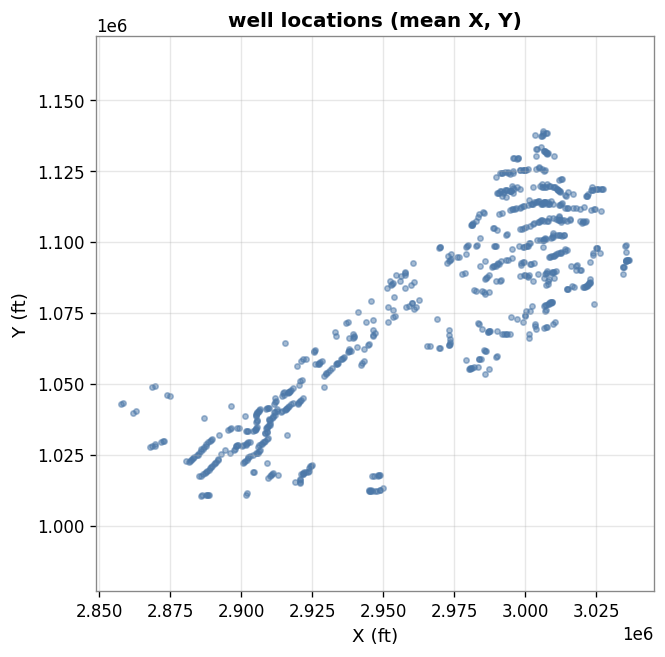

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
hist_annot(ax[0], S.n_rows, "rows per well", "rows", n0)
hist_annot(ax[1], S.md_step, "median MD step", "ft", lambda v: f"{v:.2f} ft")
hist_annot(ax[2], S.z_span, "Z span per well", "ft", ft0)
plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(S.x_mean, S.y_mean, s=10, alpha=0.5, color=BAR)
plt.title("well locations (mean X, Y)"); plt.xlabel("X (ft)"); plt.ylabel("Y (ft)"); plt.axis("equal")
plt.show()

## 5. Lateral gamma-ray (GR)

`GR` is the only direct rock signal and has extended gaps. We look at its values, the per-well missing fraction,
and whether gaps differ before vs after PS (points above the diagonal = more missing after PS).

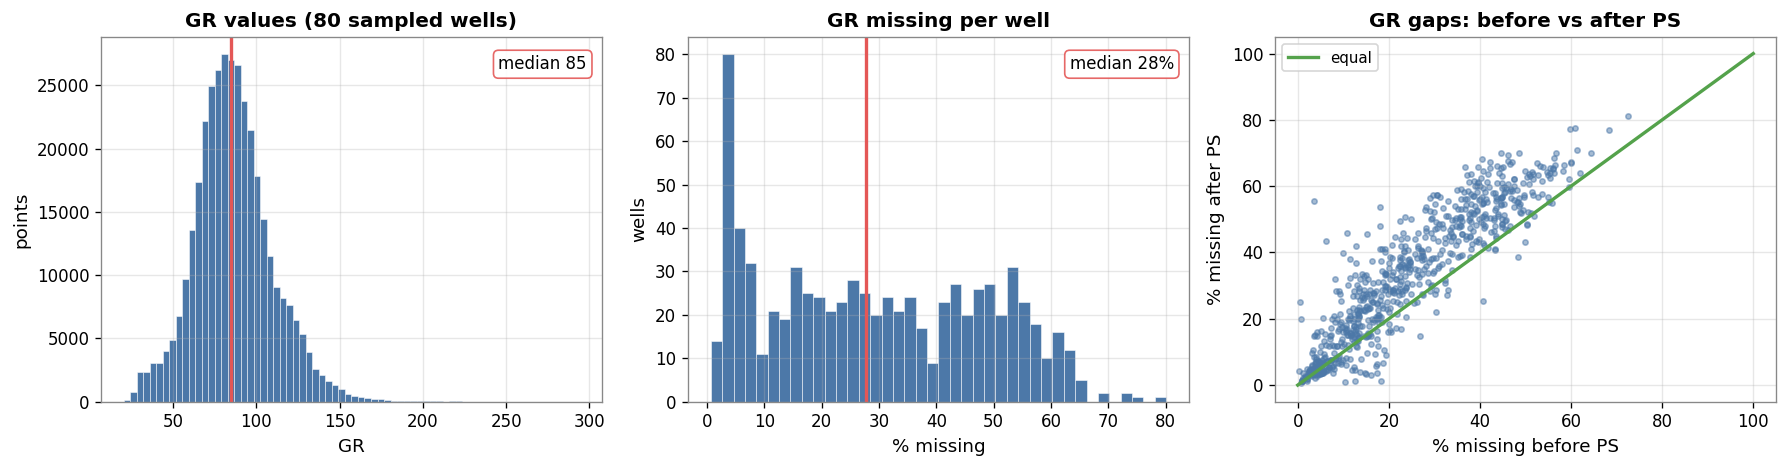

In [7]:
rng = np.random.default_rng(0)
samp = [train_h[k] for k in rng.choice(len(train_h), 80, replace=False)]
gr_vals = np.concatenate([pd.read_csv(p, usecols=["GR"]).GR.dropna().values for p in samp])

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
hist_annot(ax[0], gr_vals, "GR values (80 sampled wells)", "GR", lambda v: f"{v:.0f}", bins=70, ylabel="points")
hist_annot(ax[1], S.gr_nan_frac * 100, "GR missing per well", "% missing", lambda v: f"{v:.0f}%")
ax[2].scatter(S.gr_nan_frac_pre * 100, S.gr_nan_frac_post * 100, s=10, alpha=0.5, color=BAR)
ax[2].plot([0, 100], [0, 100], color=ID, lw=2, label="equal")
ax[2].set_xlabel("% missing before PS"); ax[2].set_ylabel("% missing after PS")
ax[2].set_title("GR gaps: before vs after PS"); ax[2].legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

## 6. Target: TVT

The prediction target. Below: per-well span, then `TVT` along four wells with the PS marker (red dashed)
splitting known from to-be-predicted. Depth axis inverted (deeper = down).

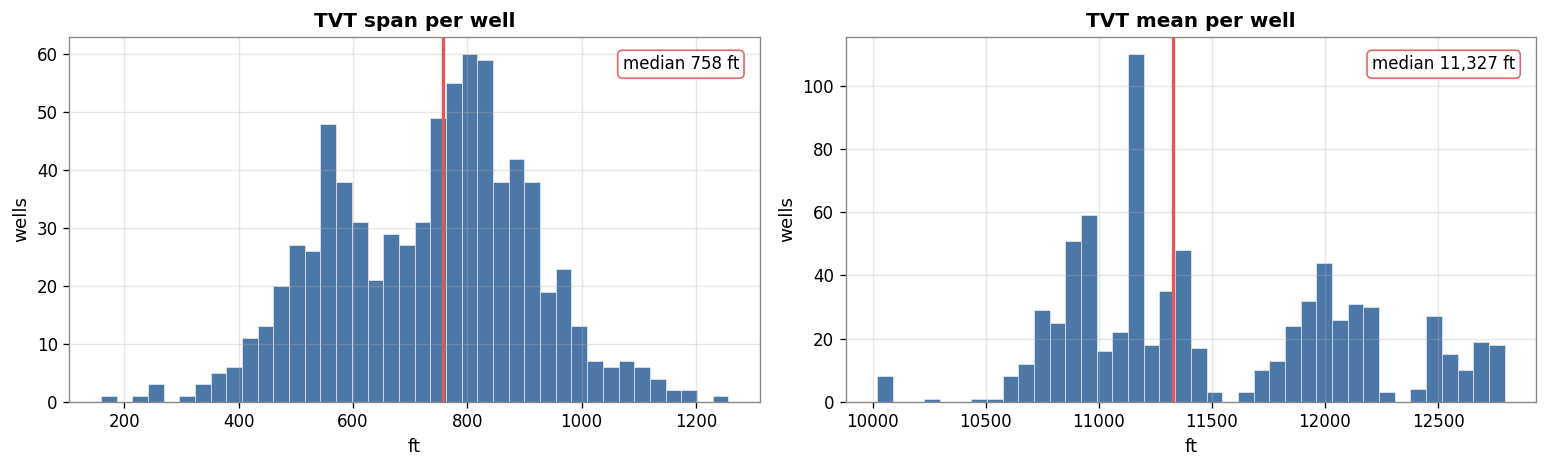

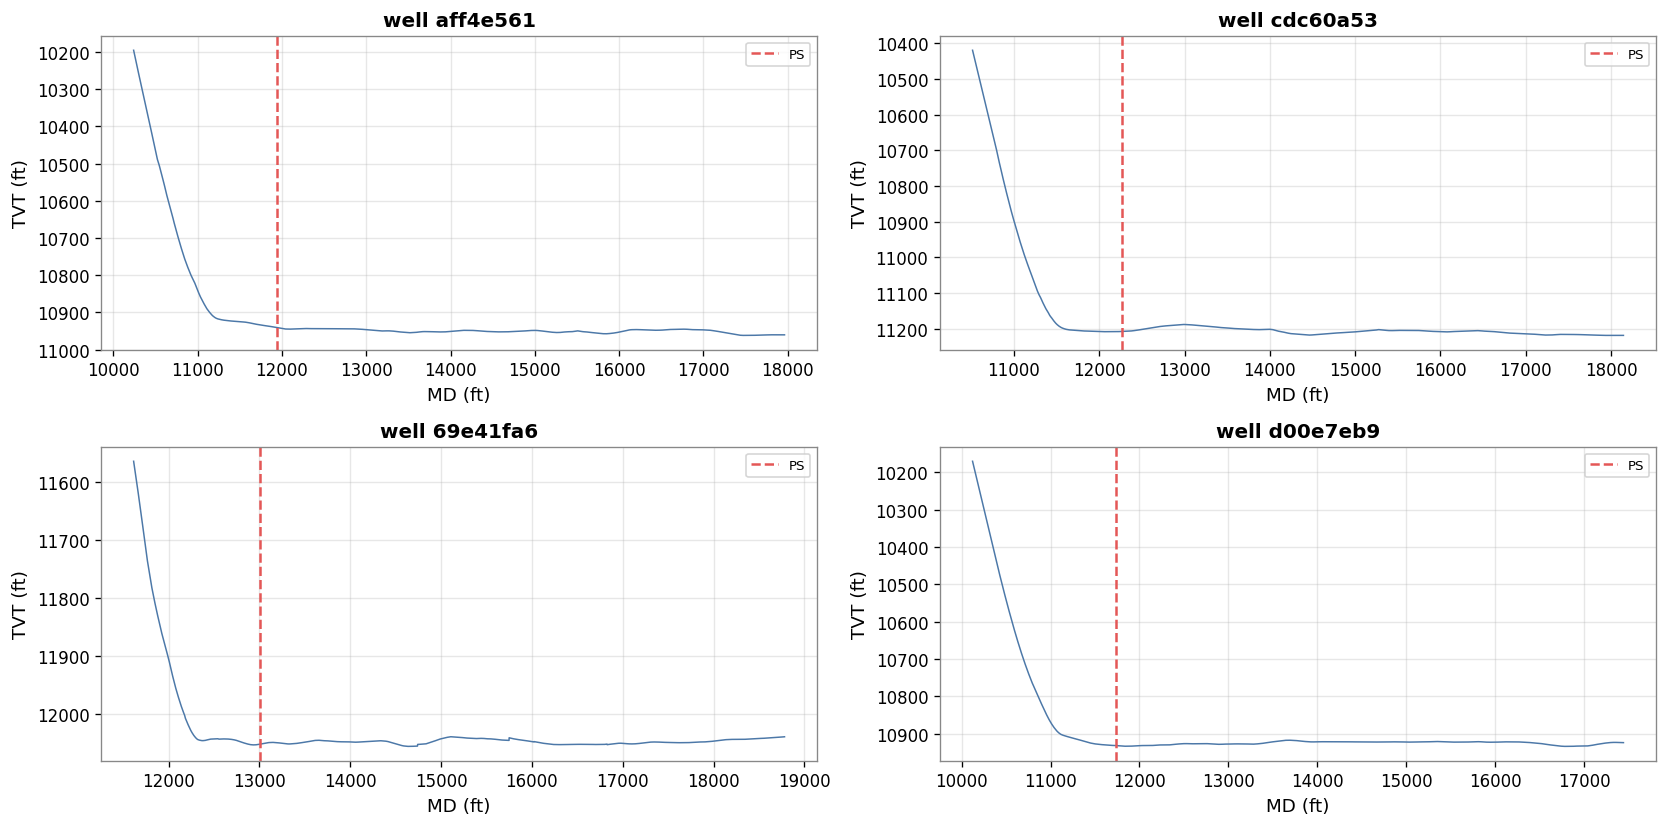

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
hist_annot(ax[0], S.tvt_span, "TVT span per well", "ft", ft0)
hist_annot(ax[1], S.tvt_mean, "TVT mean per well", "ft", ft0)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(2, 2, figsize=(14, 7))
for a, p in zip(ax.ravel(), samp[:4]):
    h = pd.read_csv(p, usecols=["MD", "TVT", "TVT_input"])
    a.plot(h.MD, h.TVT, lw=0.9, color=BAR)
    ps = int(h["TVT_input"].isna().values.argmax())
    a.axvline(h.MD.iloc[ps], color=MED, ls="--", lw=1.5, label="PS")
    a.invert_yaxis(); a.set_title(f"well {wid(p)}"); a.set_xlabel("MD (ft)"); a.set_ylabel("TVT (ft)")
    a.legend(fontsize=8, loc="best")
plt.tight_layout(); plt.show()

## 7. Prediction Start (PS)

How much of each well is known vs must be predicted.

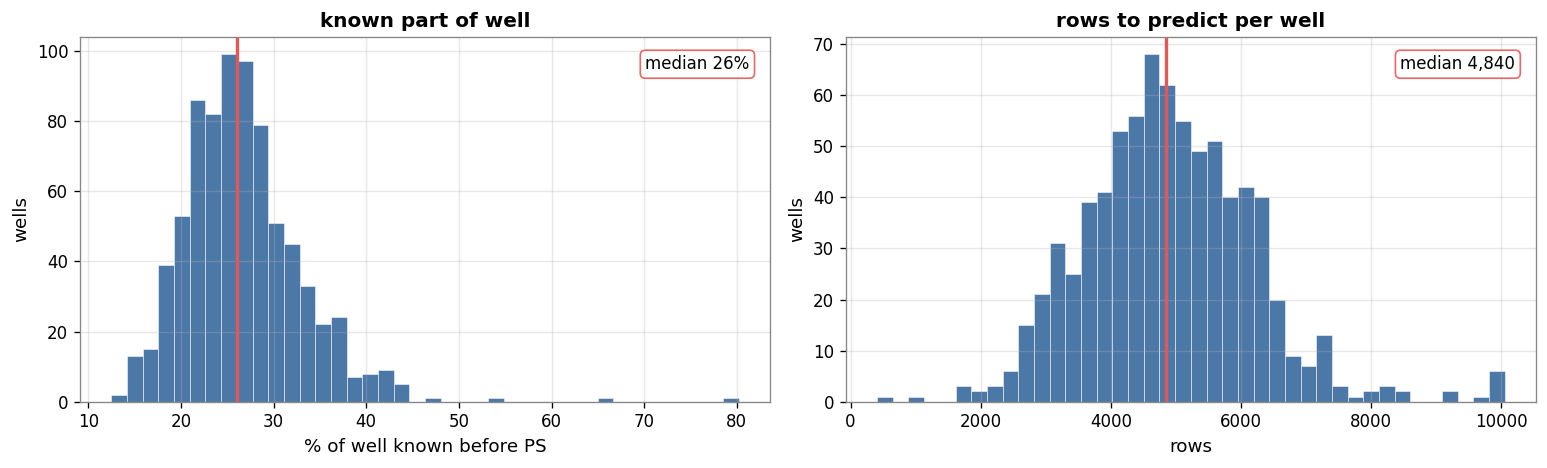

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
hist_annot(ax[0], S.ps_frac * 100, "known part of well", "% of well known before PS", lambda v: f"{v:.0f}%")
hist_annot(ax[1], S.n_predict, "rows to predict per well", "rows", n0)
plt.tight_layout(); plt.show()

## 8. Typewell (vertical reference)

`GR` vs `TVT` from a vertical well. Does it cover the lateral's TVT range, and is its `GR` on the same scale as
the lateral's? (points off the diagonal in the middle panel = scale mismatch for that well.)

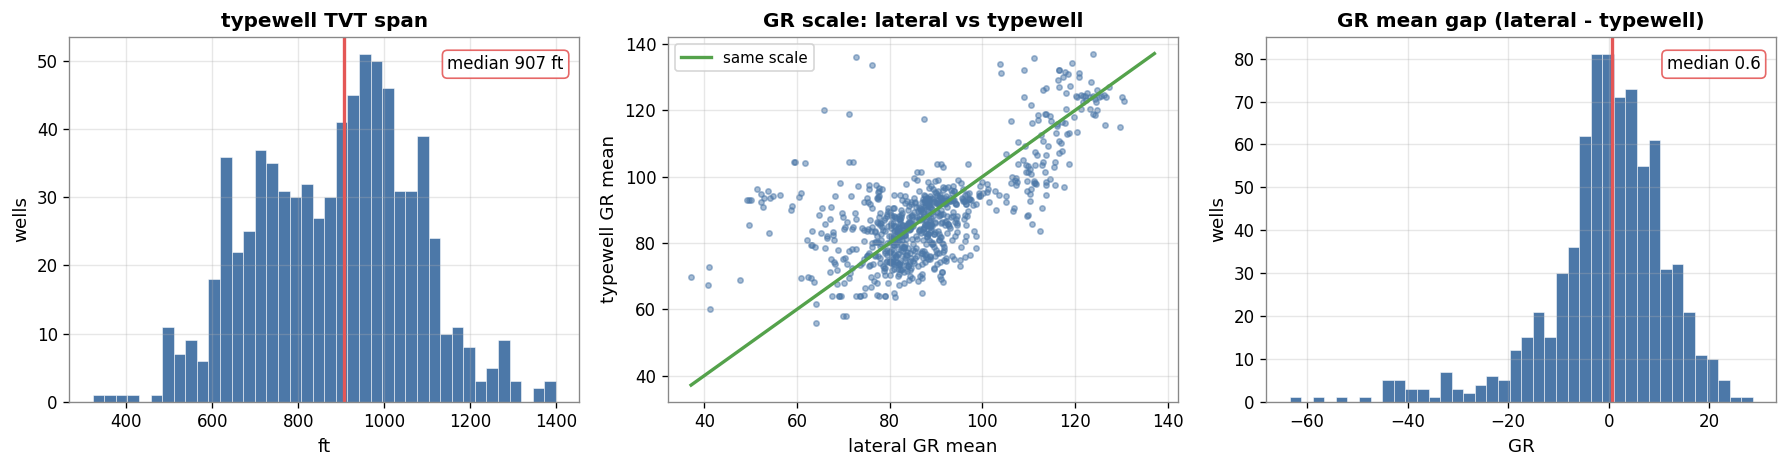

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
hist_annot(ax[0], S.tw_tvt_span, "typewell TVT span", "ft", ft0)
ax[1].scatter(S.gr_mean, S.tw_gr_mean, s=10, alpha=0.5, color=BAR)
lims = [min(S.gr_mean.min(), S.tw_gr_mean.min()), max(S.gr_mean.max(), S.tw_gr_mean.max())]
ax[1].plot(lims, lims, color=ID, lw=2, label="same scale")
ax[1].set_xlabel("lateral GR mean"); ax[1].set_ylabel("typewell GR mean")
ax[1].set_title("GR scale: lateral vs typewell"); ax[1].legend(fontsize=9)
hist_annot(ax[2], S.gr_scale_gap, "GR mean gap (lateral - typewell)", "GR", lambda v: f"{v:.1f}")
plt.tight_layout(); plt.show()

43 distinct Geology labels; 6 appear in nearly every well, the rest are rare.


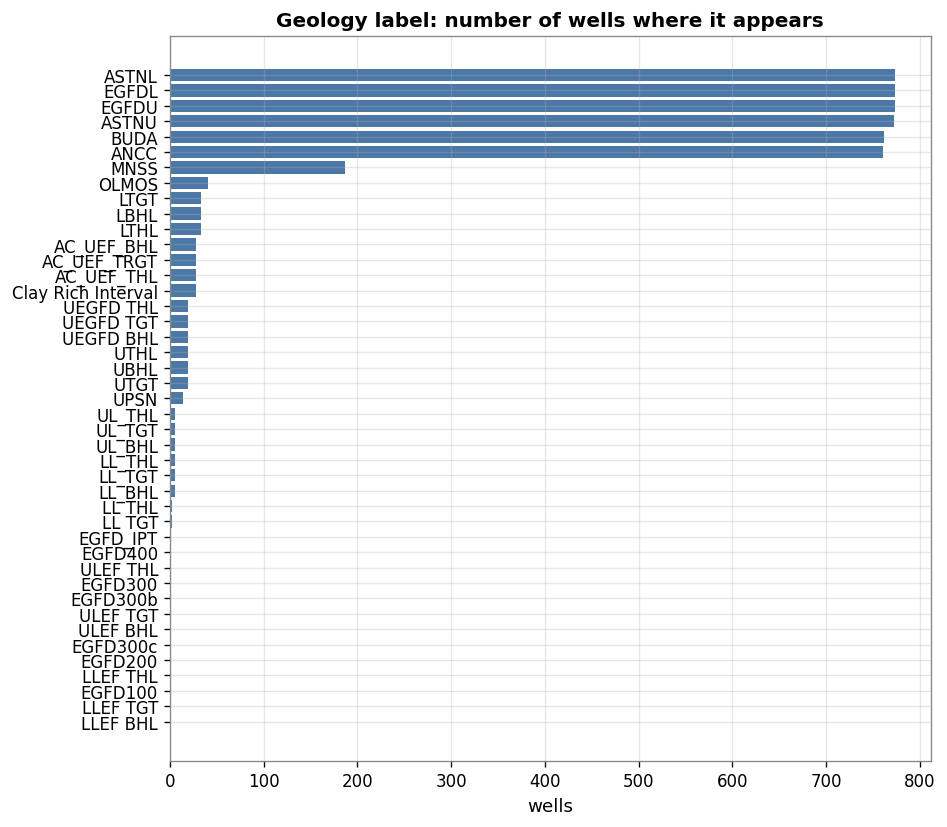

In [11]:
geo = Counter()
for p in train_h:
    geo.update(pd.read_csv(tw_path(p), usecols=["Geology"]).Geology.dropna().unique())
gf = pd.Series(geo).sort_values(ascending=False)
print(f"{len(gf)} distinct Geology labels; 6 appear in nearly every well, the rest are rare.")
plt.figure(figsize=(8, 7))
plt.barh(gf.index[::-1], gf.values[::-1], color=BAR)
plt.title("Geology label: number of wells where it appears"); plt.xlabel("wells")
plt.tight_layout(); plt.show()

## 9. Layer-boundary columns (`ANCC … BUDA`, training only)

Six per-row formation-boundary depths (in `Z`, below sea level). **Training only — they encode the target and
must never be model inputs.** Shown for understanding. (Sampled wells.)

In [12]:
rows = []
for p in samp:
    d = pd.read_csv(p, usecols=lambda c: c in LAYER_COLS)
    for c in LAYER_COLS:
        if c in d:
            rows.append({"layer": c, "min": d[c].min(), "max": d[c].max(), "nan%": d[c].isna().mean() * 100})
LB = (pd.DataFrame(rows).groupby("layer")
      .agg(min_depth=("min", "min"), max_depth=("max", "max"), missing_pct=("nan%", "mean"))).loc[LAYER_COLS]
LB = LB.assign(min_depth=LB.min_depth.map(lambda v: f"{v:,.0f} ft"),
               max_depth=LB.max_depth.map(lambda v: f"{v:,.0f} ft"),
               missing_pct=LB.missing_pct.map(lambda v: f"{v:.1f}%"))
LB.style.set_properties(**{"text-align": "right"})

,min_depth,max_depth,missing_pct
layer,,,
ANCC,"-10,334 ft","-7,303 ft",1.2%
ASTNU,"-10,567 ft","-7,510 ft",0.0%
ASTNL,"-10,623 ft","-7,616 ft",0.0%
EGFDU,"-10,654 ft","-7,705 ft",0.0%
EGFDL,"-10,704 ft","-7,733 ft",0.0%
BUDA,"-10,871 ft","-7,837 ft",0.0%


## 10. Representative wells gallery

Four wells: lateral GR vs MD · TVT vs MD (PS dashed) · typewell GR vs TVT.

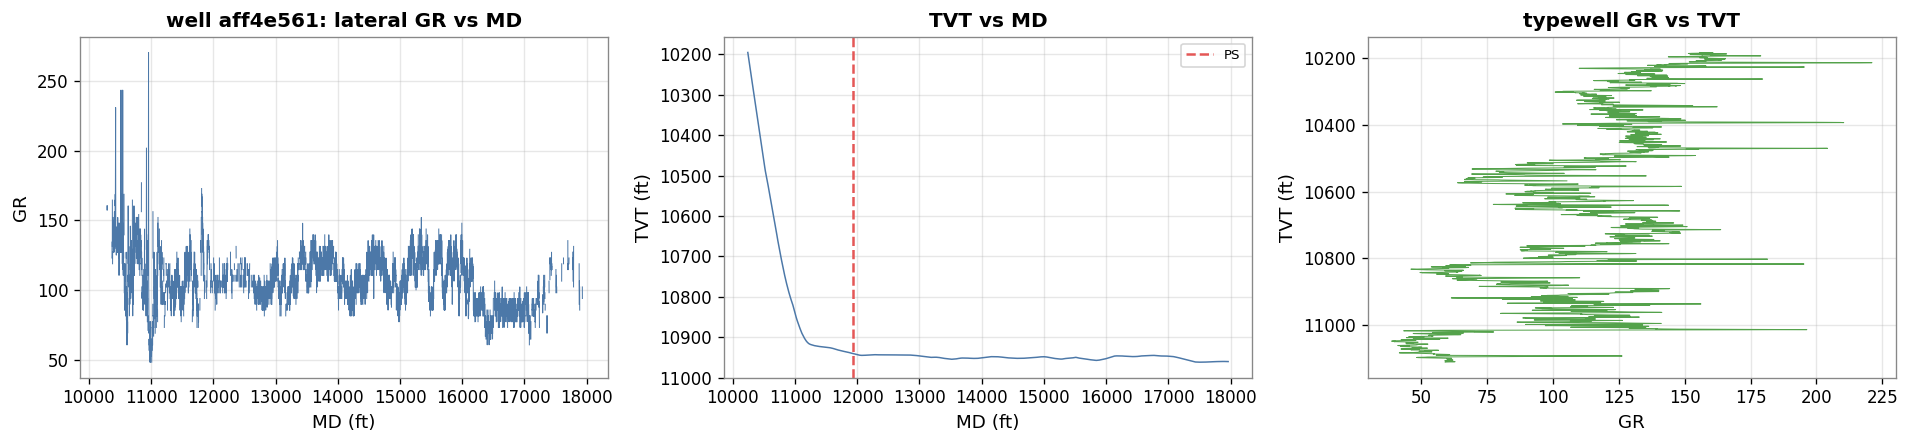

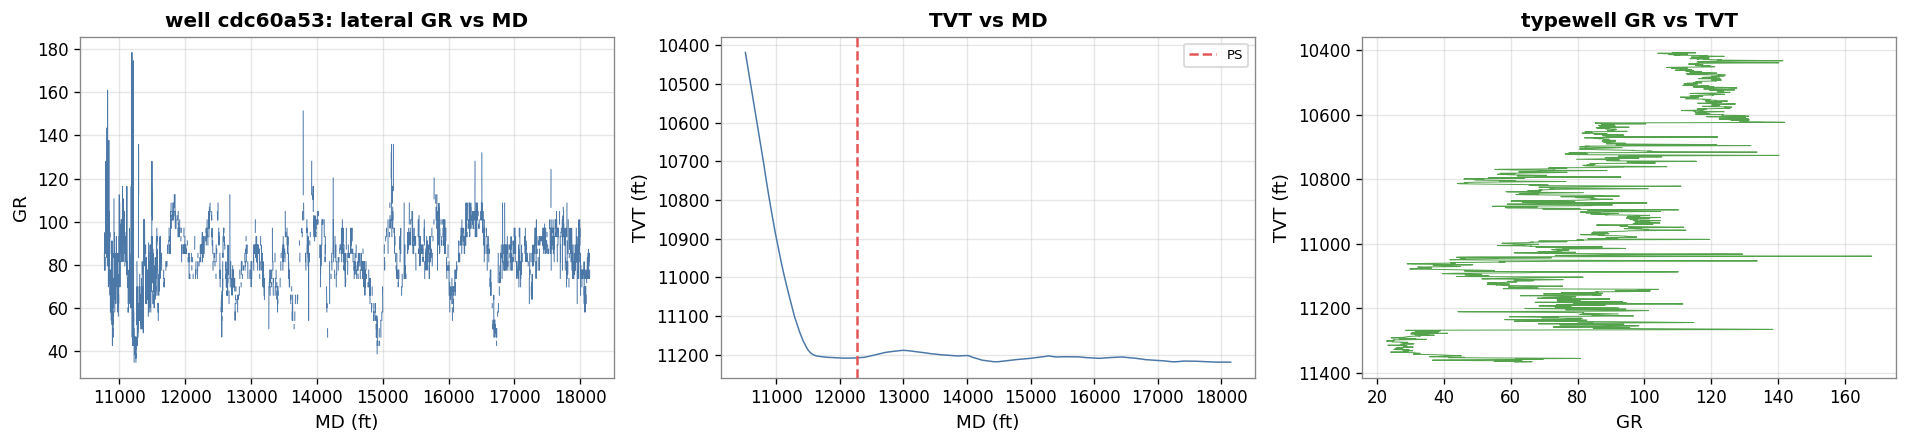

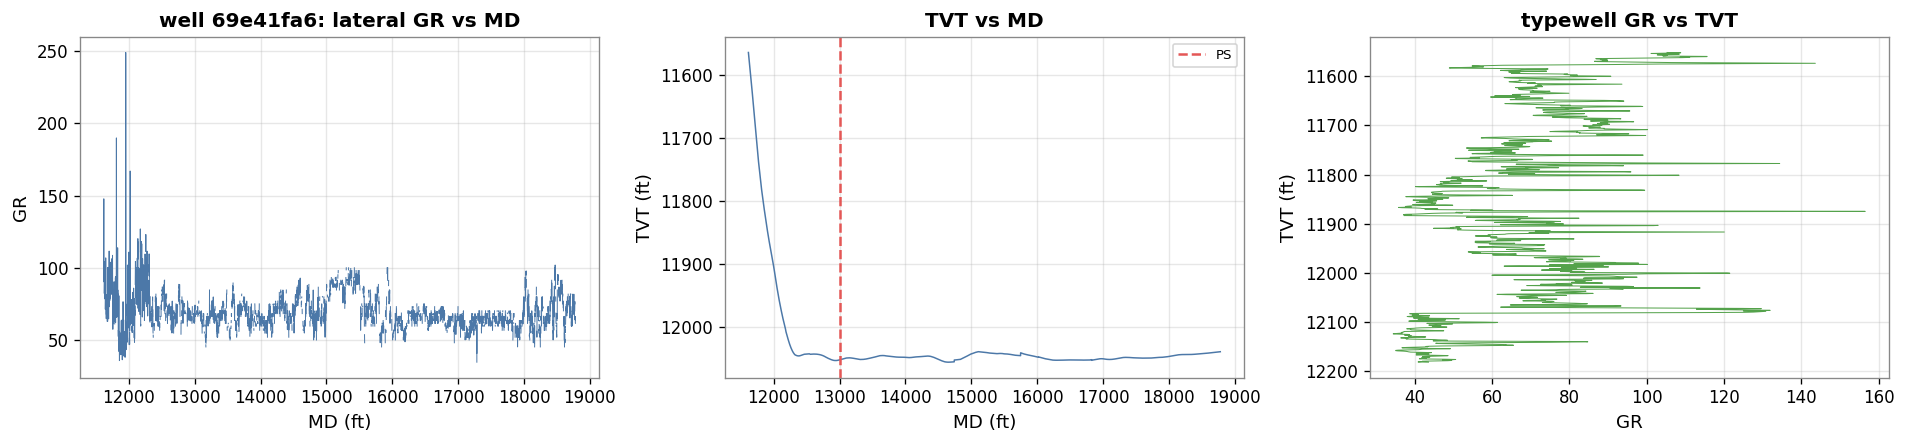

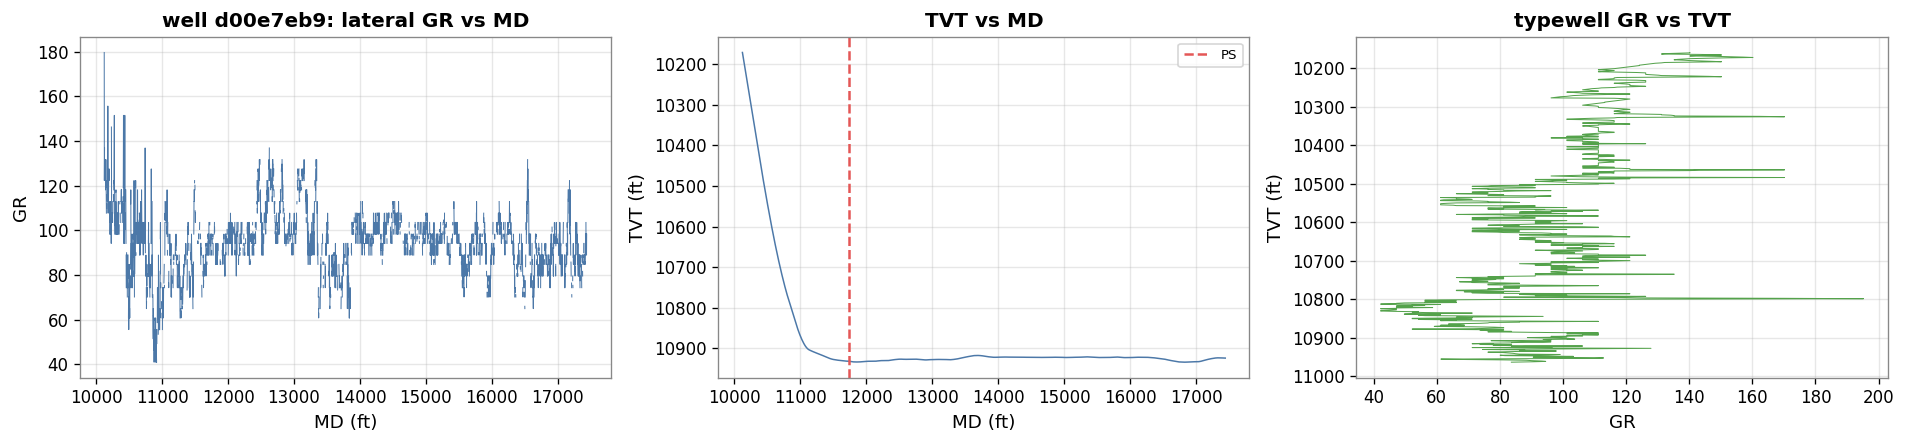

In [13]:
for p in samp[:4]:
    i = wid(p)
    h = pd.read_csv(p, usecols=["MD", "GR", "TVT", "TVT_input"])
    tw = pd.read_csv(tw_path(p), usecols=["TVT", "GR"])
    fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
    ax[0].plot(h.MD, h.GR, lw=0.6, color=BAR); ax[0].set_title(f"well {i}: lateral GR vs MD")
    ax[0].set_xlabel("MD (ft)"); ax[0].set_ylabel("GR")
    ax[1].plot(h.MD, h.TVT, lw=0.9, color=BAR)
    ps = int(h["TVT_input"].isna().values.argmax())
    ax[1].axvline(h.MD.iloc[ps], color=MED, ls="--", lw=1.5, label="PS")
    ax[1].invert_yaxis(); ax[1].set_title("TVT vs MD"); ax[1].set_xlabel("MD (ft)"); ax[1].set_ylabel("TVT (ft)")
    ax[1].legend(fontsize=8)
    ax[2].plot(tw.GR, tw.TVT, lw=0.6, color=ID); ax[2].invert_yaxis()
    ax[2].set_title("typewell GR vs TVT"); ax[2].set_xlabel("GR"); ax[2].set_ylabel("TVT (ft)")
    plt.tight_layout(); plt.show()

## Findings & analysis

**Facts (measured in this notebook)**
- 773 train wells, 3 test wells; every well has its full file set.
- Rows/well: median 6,576 (range 2,058–12,141); MD step is exactly 1 ft everywhere.
- Prediction Start sits at ~26% of the well → ~74% of every well must be predicted (median 4,840 rows, up to 10,052).
- GR missing: median 28% per well (worst ~80%); missingness is higher after PS (~30%) than before (~20%).
- GR scale differs per well: lateral−typewell mean gap has std 12 (range −63…+29); typewell GR varies more than lateral GR (std 30 vs 18).
- TVT is large in absolute terms (~10,800–11,600 ft); span within a well median 758 ft. Z span median 787 ft.
- Geology has 43 labels: 6 near-universal (ANCC, ASTNU, ASTNL, EGFDU, EGFDL, BUDA), the rest rare.
- Blank `TVT_input` rows are always a clean contiguous tail (all 773 wells).

**Analysis**
- Long horizon + GR sparser after PS → the matching signal is weakest exactly where we predict; a GR-only method will struggle in the far tail.
- GR scale varies well-to-well → any GR normalization must be per-well, not a single global shift.
- TVT span ≈ Z span → geometry (Z) plausibly explains much of TVT; this is the hypothesis notebook 02 tests.
- Uniform 1-ft sampling + clean PS tail → indexing is simple and reliable; no resampling or PS-detection logic needed.